In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
data = pd.read_csv('dataset\Melbourne.csv')
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\KIIT\AppData\Local\Temp\ipykernel_24364\3218516080.py:1: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('dataset\Melbourne.csv')


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,03-09-2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,03-12-2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,04-02-2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,04-02-2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,04-03-2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [4]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23547 entries, 0 to 23546
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         23547 non-null  object 
 1   Address        23547 non-null  object 
 2   Rooms          23547 non-null  int64  
 3   Type           23547 non-null  object 
 4   Price          18396 non-null  float64
 5   Method         23547 non-null  object 
 6   SellerG        23547 non-null  object 
 7   Date           23547 non-null  object 
 8   Distance       23546 non-null  float64
 9   Postcode       23546 non-null  float64
 10  Bedroom2       19066 non-null  float64
 11  Bathroom       19063 non-null  float64
 12  Car            18921 non-null  float64
 13  Landsize       17410 non-null  float64
 14  BuildingArea   10018 non-null  float64
 15  YearBuilt      11540 non-null  float64
 16  CouncilArea    15656 non-null  object 
 17  Lattitude      19243 non-null  float64
 18  Longti

Suburb               0
Address              0
Rooms                0
Type                 0
Price             5151
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          4481
Bathroom          4484
Car               4626
Landsize          6137
BuildingArea     13529
YearBuilt        12007
CouncilArea       7891
Lattitude         4304
Longtitude        4304
Regionname           1
Propertycount        1
dtype: int64

In [5]:
data.drop_duplicates(inplace=True)

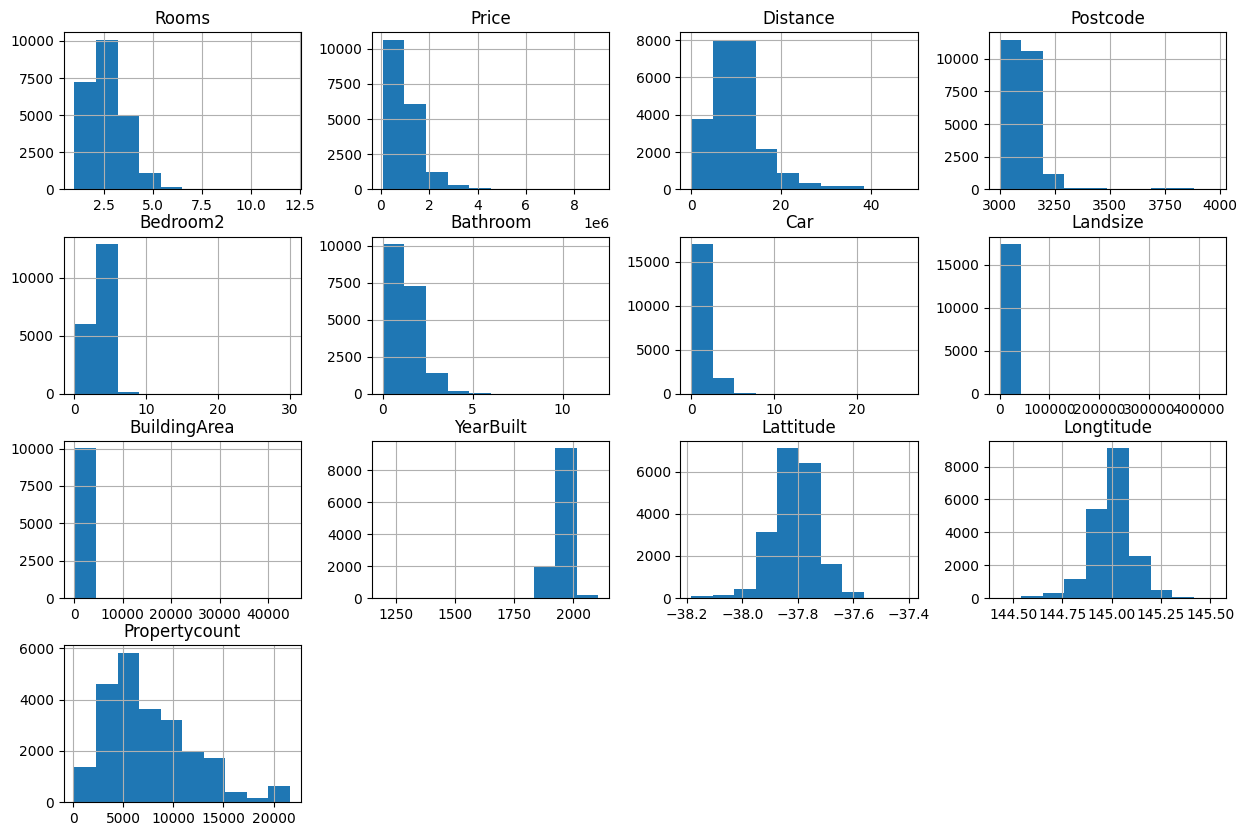

In [6]:
data.hist(figsize=(15, 10))
plt.show()

In [7]:
data.skew(numeric_only=True)

Rooms              0.502234
Price              2.366673
Distance           1.674239
Postcode           4.163519
Bedroom2           1.667123
Bathroom           1.433446
Car                2.136269
Landsize         106.064268
BuildingArea      88.594345
YearBuilt         -1.228584
Lattitude         -0.316555
Longtitude        -0.312335
Propertycount      1.056643
dtype: float64

In [8]:
for c in data.columns:
    if data[c].dtype != 'object':
        s = data[c].skew()

        if s > 0.5:
            data[c].fillna(data[c].median(), inplace=True)
        else:
            data[c].fillna(data[c].mean(), inplace=True)

    else:
        data[c].fillna(data[c].mode()[0], inplace=True)

C:\Users\KIIT\AppData\Local\Temp\ipykernel_24364\111903940.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[c].fillna(data[c].mode()[0], inplace=True)
C:\Users\KIIT\AppData\Local\Temp\ipykernel_24364\111903940.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [9]:
data.isnull().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [10]:
data.head()
data = data.drop(columns=['Address','Date'])
data.head()


,Suburb,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,2,h,880000.0,SS,Jellis,2.5,3067.0,2.0,1.0,1.0,126.0,129.0,1964.633677,Yarra,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,2,h,1480000.0,S,Biggin,2.5,3067.0,2.0,1.0,1.0,202.0,129.0,1964.633677,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,2,h,1035000.0,S,Biggin,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.000000,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,3,u,880000.0,VB,Rounds,2.5,3067.0,3.0,2.0,1.0,0.0,129.0,1964.633677,Yarra,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,3,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.000000,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [11]:
data['Suburb'].nunique()
le = LabelEncoder()
data['Type'] = le.fit_transform(data['Type'])


In [12]:
data = pd.get_dummies(data,columns=['Suburb', 'Method', 'SellerG', 'CouncilArea', 'Regionname'],dtype=int)
data.drop(columns=['Suburb', 'Method', 'SellerG', 'CouncilArea', 'Regionname'], axis=1, errors='ignore', inplace=True)
# safe drop columns after one-hot encoding

data

,Rooms,Type,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,...,CouncilArea_Yarra,CouncilArea_Yarra Ranges,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,2,0,880000.0,2.5,3067.0,2.0,1.0,1.0,126.0,129.0,...,1,0,0,0,1,0,0,0,0,0
1,2,0,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,129.0,...,1,0,0,0,1,0,0,0,0,0
2,2,0,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,...,1,0,0,0,1,0,0,0,0,0
3,3,2,880000.0,2.5,3067.0,3.0,2.0,1.0,0.0,129.0,...,1,0,0,0,1,0,0,0,0,0
4,3,0,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,...,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23542,3,2,880000.0,27.2,3024.0,3.0,1.0,0.0,552.0,119.0,...,0,0,0,0,0,0,0,0,1,0
23543,4,0,880000.0,27.2,3024.0,3.0,1.0,2.0,448.0,129.0,...,0,0,0,0,0,0,0,0,1,0
23544,4,0,1100000.0,12.7,3085.0,4.0,3.0,2.0,448.0,129.0,...,0,0,0,0,1,0,0,0,0,0
23545,4,0,1285000.0,6.3,3013.0,4.0,1.0,1.0,362.0,112.0,...,0,0,0,0,0,0,0,0,1,0


In [13]:
scaler = StandardScaler()
data[['Postcode','Price','Landsize','BuildingArea']] = scaler.fit_transform(data[['Postcode','Price','Landsize','BuildingArea']])
data

,Rooms,Type,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,...,CouncilArea_Yarra,CouncilArea_Yarra Ranges,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,2,0,-0.241320,2.5,-0.452619,2.0,1.0,1.0,-0.130823,-0.035957,...,1,0,0,0,1,0,0,0,0,0
1,2,0,0.807518,2.5,-0.452619,2.0,1.0,1.0,-0.105888,-0.035957,...,1,0,0,0,1,0,0,0,0,0
2,2,0,0.029630,2.5,-0.452619,2.0,1.0,0.0,-0.120980,-0.201547,...,1,0,0,0,1,0,0,0,0,0
3,3,2,-0.241320,2.5,-0.452619,3.0,2.0,1.0,-0.172162,-0.035957,...,1,0,0,0,1,0,0,0,0,0
4,3,0,0.781297,2.5,-0.452619,3.0,2.0,0.0,-0.128198,0.033591,...,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23542,3,2,-0.241320,27.2,-0.907549,3.0,1.0,0.0,0.008944,-0.069075,...,0,0,0,0,0,0,0,0,1,0
23543,4,0,-0.241320,27.2,-0.907549,3.0,1.0,2.0,-0.025178,-0.035957,...,0,0,0,0,0,0,0,0,1,0
23544,4,0,0.143254,12.7,-0.262184,4.0,3.0,2.0,-0.025178,-0.035957,...,0,0,0,0,1,0,0,0,0,0
23545,4,0,0.466646,6.3,-1.023926,4.0,1.0,1.0,-0.053393,-0.092257,...,0,0,0,0,0,0,0,0,1,0


In [14]:
x = data.drop(columns=['Price'])
y = data['Price']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=42)

In [15]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(x_test)
model.score(x_test, y_test)
model.score(x_train,y_train)

0.4735080784513971

In [17]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:", mae)
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:',mse)
r2 = r2_score(y_test,y_pred)
print('R2 score:',r2)

Mean Absolute Error: 0.4817671796792726
Mean Squared Error: 0.5636833024938849
R2 score: 0.44843886290712753


In [18]:
ridge = Ridge(alpha=50)
ridge.fit(x_train, y_train)
y_pred = ridge.predict(x_test)
r_score = ridge.score(x_test, y_test)
print("Ridge Regression R2 Score:", r_score)

Ridge Regression R2 Score: 0.4516448325055956


In [19]:
lasso = Lasso(alpha=55)
lasso.fit(x_train, y_train)
y_pred = lasso.predict(x_test)
lasso.score(x_test, y_test)

0.0018211720093790351

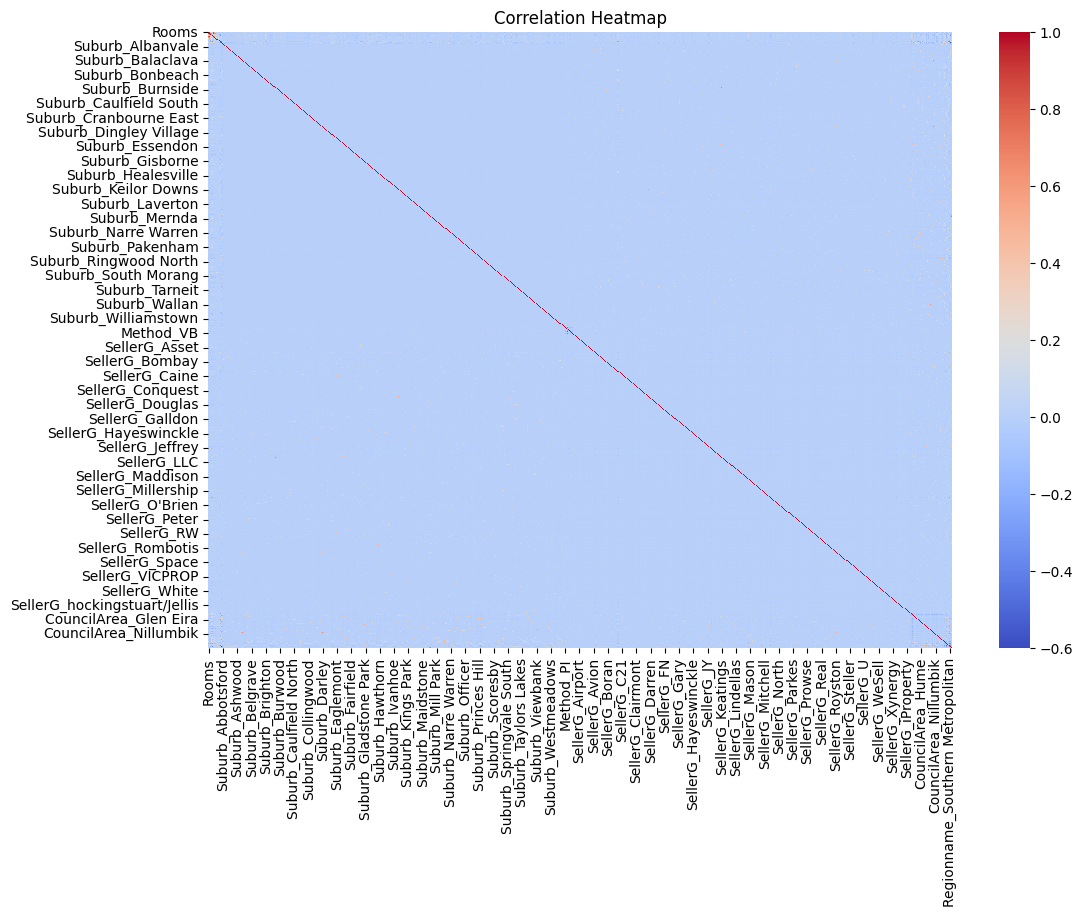

In [20]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

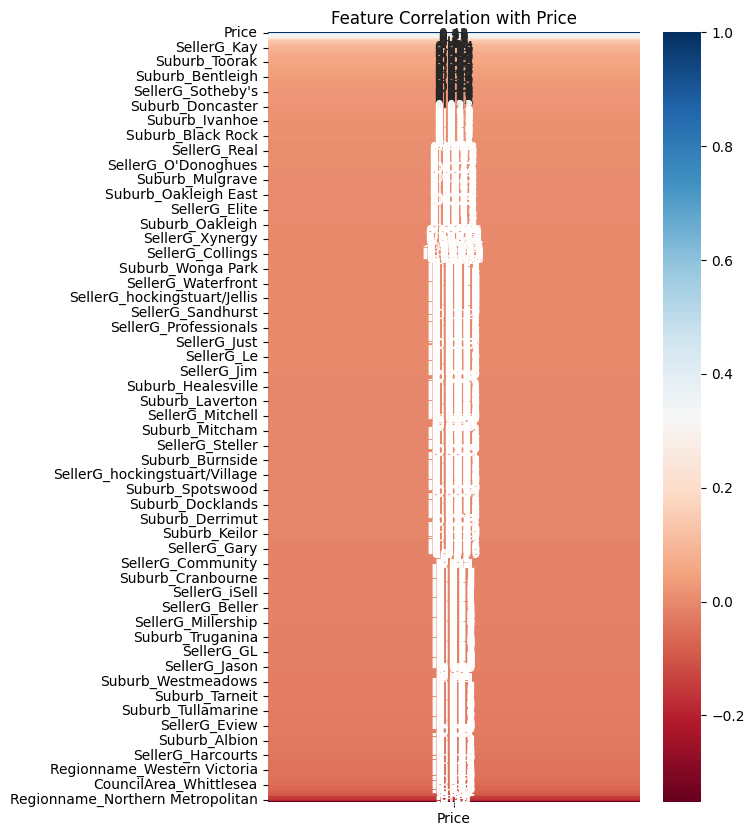

In [21]:
price_corr = corr[['Price']].sort_values(by='Price', ascending=False)

plt.figure(figsize=(6,10))
sns.heatmap(price_corr, annot=True, cmap='RdBu')
plt.title("Feature Correlation with Price")
plt.show()